# CrisisBench
The Crisis Benchmarks Dataset consists of data from different data sources [1]):

## A. Original description

Combined from:
- CrisisLex
- CrisisNLP
- SWDM13
- ISCRAM13
- DRD
- DSM
- CrisisMMD
- AIDR

### Data format and directories

The data directory contains the following sub-directories. In each directory, there are files for Informativeness and Humanitarian tasks.

* data/all_data_en -- all combined english dataset used for the experiments
* data/individual_data_en -- consists of data used for the experiments as individual data source such as crisisnlp and crisislex
* data/event_aware_en -- all combined english dataset with event tag (fire, earthquake, flood, ...) are tagged
* data/data_split_all_lang -- all combined dataset with their train/dev and test splits
* data/initial_filtering -- all combined dataset duplicate removed data
* data/class_label_mapped -- all combined dataset initial set of dataset where class label mapped

#### Format of the TSV files

Each TSV file contains the following columns, separated by a tab:

* id: corresponds to the user tweet id from Twitter.
* event: event name associated with the respective dataset
* source: source of the dataset
* text: tweet text.
* lang: language tag obtained either from Twitter or obtained from Google language detection API
* lang conf: confidence score obtained from Google language detection API; for many cases, there are tag "NA", which represents that the language tag is obtained from Twitter from Google API
* class_label: class label a given tweet text.


### Citation

* Firoj Alam, Hassan Sajjad, Muhammad Imran and Ferda Ofli, CrisisBench: Benchmarking Crisis-related Social Media Datasets for Humanitarian Information Processing, In ICWSM, 2021.
* Muhammad Imran, Prasenjit Mitra, Carlos Castillo. Twitter as a Lifeline: Human-annotated Twitter Corpora for NLP of Crisis-related Messages. In Proceedings of the 10th Language Resources and Evaluation Conference (LREC), 2016, Slovenia.
* A. Olteanu, S. Vieweg, C. Castillo. 2015. What to Expect When the Unexpected Happens: Social Media Communications Across Crises. In Proceedings of the ACM 2015 Conference on Computer Supported Cooperative Work and Social Computing (CSCW '15). ACM, Vancouver, BC, Canada.
* A. Olteanu, C. Castillo, F. Diaz, S. Vieweg. 2014. CrisisLex: A Lexicon for Collecting and Filtering Microblogged Communications in Crises. In Proceedings of the AAAI Conference on Weblogs and Social Media (ICWSM'14). AAAI Press, Ann Arbor, MI, USA.
* Muhammad Imran, Shady Elbassuoni, Carlos Castillo, Fernando Diaz and Patrick Meier. Practical Extraction of Disaster-Relevant Information from Social Media. In Social Web for Disaster Management (SWDM'13) - Co-located with WWW, May 2013, Rio de Janeiro, Brazil.
* Muhammad Imran, Shady Elbassuoni, Carlos Castillo, Fernando Diaz and Patrick Meier. Extracting Information Nuggets from Disaster-Related Messages in Social Media. In Proceedings of the 10th International Conference on Information Systems for Crisis Response and Management (ISCRAM), May 2013, Baden-Baden, Germany.

## B. Overview

There are three english-related sub sets, which author did not clearly explain.

1. class_label_mapped

    Overlapped but not identical.
    It is the Second column `Mapping` on Table 1 of the paper
    
    - crisis_consolidated_humanitarian.tsv
    - crisis_consolidated_informativeness.tsv

1. initial_filtering

    The `*_filtered_lang` have language detection columns, while the `*_filtered` have `text_formatted` column. They are identical set of tweets

    `humanitarian` and `informativeness` are overlapped but not indentical

    It is the Third column `Filtering` on Table 1 of the paper

    - crisis_consolidated_humanitarian_filtered_lang.tsv
    - crisis_consolidated_humanitarian_filtered.tsv
    - crisis_consolidated_informativeness_filtered_lang.tsv
    - crisis_consolidated_informativeness_filtered.tsv

1. all_data_en

    Overlapped but not identical

    - crisis_consolidated_humanitarian_filtered_lang_en_dev.tsv
    - crisis_consolidated_humanitarian_filtered_lang_en_test.tsv
    - crisis_consolidated_humanitarian_filtered_lang_en_train.tsv
    - crisis_consolidated_informativeness_filtered_lang_en_dev.tsv
    - crisis_consolidated_informativeness_filtered_lang_en_test.tsv
    - crisis_consolidated_informativeness_filtered_lang_en_train.tsv

According to the paper, the order of sets is `class_label_mapped` > `initial_filtering` > `all_data_en`.

Then
- `class_label_mapped` should be the supper set of both `initial_filtering` and `all_data_en`
- `initial_filtering` should be the supper set of `all_data_en`

However, the reality is,
- only `class_label_mapped` is the supper set of `initial_filtering`.
- `all_data_en` contains 443 records from `drd-figureeight-multimedia` and 4 records from `aidr_system` that are not existed in `class_label_mapped` and `initial_filtering`.

=> TODO:
- Merge 447 records from `all_data_en` back to `class_label_mapped`
- Select English only

In [32]:
from pathlib import Path
import os
import csv
import numpy as np
import pandas as pd

import configuration
from src import dataset_settings

from dotenv import load_dotenv
load_dotenv()

dataset_path = Path(os.getenv("DATASETS_PATH")) / "CrisisBench" / "data"

#### B.1. all_data_en

In [33]:
base_dir = dataset_path / "all_data_en"

informativeness_files = sorted(
    base_dir.rglob("crisis_consolidated_informativeness_filtered_lang_en_*.tsv")
)

humanitarian_files = sorted(
    base_dir.rglob("crisis_consolidated_humanitarian_filtered_lang_en_*.tsv")
)

df_inf_all_data_en = pd.concat(
    [
        pd.read_csv(
            f,
            sep="\t",
            quoting=csv.QUOTE_NONE,
            on_bad_lines="skip",
        )
        for f in informativeness_files
    ],
    ignore_index=True,
)

df_hum_all_data_en = pd.concat(
    [pd.read_csv(f, sep="\t") for f in humanitarian_files], ignore_index=True
)

In [34]:
print("Informativeness dataset:")
print(df_inf_all_data_en.shape)
print(df_inf_all_data_en.columns)
print("\nHumanitarian dataset:")
print(df_hum_all_data_en.shape)
print(df_hum_all_data_en.columns)

Informativeness dataset:
(156899, 7)
Index(['id', 'event', 'source', 'text', 'lang', 'lang_conf', 'class_label'], dtype='object')

Humanitarian dataset:
(87455, 7)
Index(['id', 'event', 'source', 'text', 'lang', 'lang_conf', 'class_label'], dtype='object')


In [35]:
set(df_inf_all_data_en[['id']]).issuperset(set(df_hum_all_data_en[['id']]))

True

In [36]:
df_inf_all_data_en.head()

,id,event,source,text,lang,lang_conf,class_label
0,778254116,disaster_events,dsm-cf,10 Ways To Survive and Escape Martial Law | Wo...,en,1.0,not_informative
1,573869823861649408,2014-2015_worldwide_landslides,crisisnlp-volunteers,Back in #sunny #Paris and bumped into these tw...,en,NaN,not_informative
2,573782587296071681,2014-2015_worldwide_landslides,crisisnlp-volunteers,@SteveStreza Otherwise a picture of our new Op...,en,NaN,not_informative
3,324742397659578368,2013_west_texas,crisislext6,This is horrible; please join us in prayer. O...,en,1.0,informative
4,508342978759245824,2014_pakistan_floods,crisisnlp-cf,@govindverma1940 @htpunjab u can b d nxt targe...,en,1.0,informative


In [37]:
df_hum_all_data_en.head()

,id,event,source,text,lang,lang_conf,class_label
0,295654395306201088,2013_queensland_floods-ontopic,crisislext6,Congrats to all my Liverpool supporting fans f...,en,1.0,not_humanitarian
1,910558750913658881,mexico_earthquake,crisismmd,collapsed buildings in Mexico City / earthquak...,en,NaN,infrastructure_and_utilities_damage
2,451190506660188160,2014_chile_earthquake,crisisnlp-cf,@estherminded here's your flower #chile http:/...,en,1.0,sympathy_and_support
3,338272854569275392,2013_oklahoma_tornado-ontopic,crisislext6,"Ready for a relaxing weekend, but have too muc...",en,1.0,not_humanitarian
4,908862255512657920,hurricane_harvey,crisismmd,Public-private information portal developed to...,en,NaN,donation_and_volunteering


#### B.2. class_label_mapped

In [38]:
base_dir = dataset_path / "class_label_mapped"

informativeness_file = base_dir / "crisis_consolidated_informativeness.tsv"
humanitarian_file =  base_dir / "crisis_consolidated_humanitarian.tsv"

df_inf_class_label_mapped = pd.read_csv(informativeness_file, sep="\t")
df_hum_class_label_mapped = pd.read_csv(humanitarian_file, sep="\t")

drop_hum_labels = ['disease_related', 'physical_landslide', 'personal_update', 'terrorism_related']
df_hum_class_label_mapped = df_hum_class_label_mapped[~df_hum_class_label_mapped['class_label'].isin(drop_hum_labels)]


In [39]:
df_hum_class_label_mapped.head()

,id,event,source,text,class_label
0,368659239272579073,2013_Manila_Floods,CrisisLexT26,RT @dost_pagasa: WEATHER BULLETIN No. 2 Tropic...,caution_and_advice
1,368673453785636864,2013_Manila_Floods,CrisisLexT26,"RT @24_Oras: Sa datos ng @dost_pagasa, huling ...",caution_and_advice
2,368676146541371392,2013_Manila_Floods,CrisisLexT26,Fuck ayoko ng baha. Paano ako sa Manila gdi pu...,not_humanitarian
3,368679682322874371,2013_Manila_Floods,CrisisLexT26,RT @ANCALERTS: Tropical Depression Maring is m...,caution_and_advice
4,368929037877403652,2013_Manila_Floods,CrisisLexT26,Intramuros baha. I miss Manila. http://t.co/Uk...,infrastructure_and_utilities_damage


In [40]:
set(df_inf_class_label_mapped[['id']]).issuperset(set(df_hum_class_label_mapped[['id']]))

True

#### B.3. Merged

In [41]:
diff_inf = set(df_inf_all_data_en['id']) - set(df_inf_class_label_mapped['id'])
diff_hum = set(df_hum_all_data_en['id']) - set(df_hum_class_label_mapped['id'])

print(len(diff_inf))
print(len(diff_hum))

447
29


In [42]:
df_inf = pd.concat([df_inf_all_data_en[df_inf_all_data_en['id'].isin(diff_inf)], df_inf_class_label_mapped], ignore_index=True)
df_hum = pd.concat([df_hum_all_data_en[df_hum_all_data_en['id'].isin(diff_hum)], df_hum_class_label_mapped], ignore_index=True)

df_inf

,id,event,source,text,lang,lang_conf,class_label
0,24960,disaster_events,drd-figureeight-multimedia,Additional projects are underway using the 'bu...,en,1.0,informative
1,19296,disaster_events,drd-figureeight-multimedia,The Punjab is currently below normal for cumul...,en,1.0,informative
2,24943,disaster_events,drd-figureeight-multimedia,Since this morning some of affected community ...,en,1.0,informative
3,24940,disaster_events,drd-figureeight-multimedia,The official with the Gansu Provincial Civil A...,en,1.0,informative
4,18743,disaster_events,drd-figureeight-multimedia,The flooding has been caused by persistent hea...,en,1.0,informative
...,...,...,...,...,...,...,...
195984,818030041930014720,disaster_events,AIDR_system,"Accident, two lanes blocked in #Hennepin on 94...",NaN,NaN,informative
195985,821167695856955392,disaster_events,AIDR_system,ACCIDENT: W/B GCP approaching I-495/LIE - 2 la...,NaN,NaN,informative
195986,821167952581902336,disaster_events,AIDR_system,"Accident, right lane blocked in Maricopa on St...",NaN,NaN,informative
195987,821184337211166721,disaster_events,AIDR_system,ROCKDALE: Bay St is closed eastbound btn the P...,NaN,NaN,informative


In [43]:
set(df_inf[['id']]).issuperset(set(df_hum[['id']]))

True

#### B.4 Clean

In [44]:
events_mapping = {
    "disaster_events": {"name": "disaster_events", "type": "disaster"},
    "2015_nepal_earthquake": {"name": "2015_nepal_earthquake", "type": "earthquake"},
    "2014_philippines_typhoon-hagupit": {
        "name": "2014_philippines_typhoon-hagupit",
        "type": "typhoon",
    },
    "2013_oklahoma_tornado-ontopic": {
        "name": "2013_oklahoma_tornado-ontopic",
        "type": "tornado",
    },
    "2013_west_texas": {"name": "2013_west_texas", "type": "flood"},
    "2013_alberta_floods-ontopic": {
        "name": "2013_alberta_floods-ontopic",
        "type": "flood",
    },
    "2013_queensland_floods-ontopic": {
        "name": "2013_queensland_floods-ontopic",
        "type": "flood",
    },
    "2012_sandy_hurricane-ontopic": {
        "name": "2012_sandy_hurricane-ontopic",
        "type": "hurricane",
    },
    "2014-2015_worldwide_landslides": {
        "name": "2014-2015_worldwide_landslides",
        "type": "landslide",
    },
    "hurricane_maria": {"name": "hurricane_maria", "type": "storm"},
    "hurricane_harvey": {"name": "hurricane_harvey", "type": "storm"},
    "hurricane_irma": {"name": "hurricane_irma", "type": "storm"},
    "2015_vanuatu_cyclone": {"name": "2015_vanuatu_cyclone", "type": "storm"},
    "2014_chile_earthquake": {"name": "2014_chile_earthquake", "type": "earthquake"},
    "2014_pakistan_floods": {"name": "2014_pakistan_floods", "type": "flood"},
    "2013_pakistan_earthquake": {
        "name": "2013_pakistan_earthquake",
        "type": "earthquake",
    },
    "2014_philippines_typhoon": {"name": "2014_philippines_typhoon", "type": "storm"},
    "california_wildfires": {"name": "california_wildfires", "type": "wildfire"},
    "2014_mexico_hurricane-odile": {
        "name": "2014_mexico_hurricane-odile",
        "type": "storm",
    },
    "mexico_earthquake": {"name": "mexico_earthquake", "type": "earthquake"},
    "2014_california_earthquake": {
        "name": "2014_california_earthquake",
        "type": "earthquake",
    },
    "2011_joplin_tornado-a121571": {
        "name": "2011_joplin_tornado-a121571",
        "type": "tornado",
    },
    "2013_alberta_floods": {"name": "2013_alberta_floods", "type": "flood"},
    "srilanka_floods": {"name": "srilanka_floods", "type": "flood"},
    "2013_phillipines_typhoon-yolanda": {
        "name": "2013_phillipines_typhoon-yolanda",
        "type": "storm",
    },
    "2013_colorado_floods": {"name": "2013_colorado_floods", "type": "flood"},
    "2013_queensland_floods": {"name": "2013_queensland_floods", "type": "flood"},
    "2013_west-texas_explosion": {
        "name": "2013_west-texas_explosion",
        "type": "explosion",
    },
    "2014_india_floods": {"name": "2014_india_floods", "type": "flood"},
    "2012_philipinnes_floods": {"name": "2012_philipinnes_floods", "type": "flood"},
    "2012_philippines_typhoon-pablo": {
        "name": "2012_philippines_typhoon-pablo",
        "type": "storm",
    },
    "2013_bohol_earthquake": {"name": "2013_bohol_earthquake", "type": "earthquake"},
    
    "2013_australia_bushfire": {"name": "2013_australia_bushfire", "type": "wildfire"},
    "2013_manila_floods": {"name": "2013_manila_floods", "type": "flood"},
    "2012_colorado_wildfires": {"name": "2012_colorado_wildfires", "type": "wildfire"},
    "2015_vanuatu_cyclone-pam": {"name": "2015_vanuatu_cyclone-pam", "type": "storm"},
    
    "2013_russia_meteor_en-mixed": {
        "name": "2013_russia_meteor_en-mixed",
        "type": "meteor",
    },
    "iraq_iran_earthquake": {"name": "iraq_iran_earthquake", "type": "earthquake"},
    "2012_us_sandy-hurricane-a144267": {
        "name": "2012_us_sandy-hurricane",
        "type": "storm",
    },
    "2014_iceland_volcano": {"name": "2014_iceland_volcano", "type": "volcano"},
    "2012_costa-rica_earthquake": {
        "name": "2012_costa-rica_earthquake",
        "type": "earthquake",
    },
    "2012_guatemala_earthquake": {
        "name": "2012_guatemala_earthquake",
        "type": "earthquake",
    },
    "2012_italy_earthquakes": {"name": "2012_italy_earthquakes", "type": "earthquake"},
    "2012_us_sandy-hurricane-a143145": {
        "name": "2012_us_sandy-hurricane-a143145",
        "type": "storm",
    },
    "2013_italy_sardinia": {"name": "2013_italy_sardinia", "type": "flood"},
    "2011_joplin_tornado-a131709": {"name": "2011_joplin_tornado", "type": "tornado"},
    '2011_Joplin_Tornado-a121571': {"name": "2011_joplin_tornado", "type": "tornado"},
    '2011_Joplin_Tornado-a131709': {"name": "2011_joplin_tornado", "type": "tornado"},
    '2012_Colorado_Wildfires': {"name": "2012_colorado_wildfires", "type": "wildfire"},
    '2012_Costa-Rica_Earthquake': {"name": "2012_costa-rica_earthquake", "type": "earthquake"},
    '2012_Guatemala_Earthquake': {"name": "2012_guatemala_earthquake", "type": "earthquake"},
    '2012_Italy_Earthquakes': {"name": "2012_italy_earthquakes", "type": "earthquake"},
    '2012_Philipinnes_Floods': {"name": "2012_philipinnes_floods", "type": "flood"},
    '2012_Philippines_Typhoon-Pablo': {"name": "2012_philippines_typhoon-pablo", "type": "storm"},
    '2012_Sandy_Hurricane-ontopic': {"name": "2012_us_sandy-hurricane", "type": "storm"},
    '2012_US_Sandy-Hurricane-a143145': {"name": "2012_us_sandy-hurricane", "type": "storm"},
    '2012_US_Sandy-Hurricane-a144267': {"name": "2012_us_sandy-hurricane", "type": "storm"},
    '2013_Alberta_Floods': {"name": "2013_alberta_floods", "type": "flood"},
    '2013_Alberta_Floods-ontopic': {"name": "2013_alberta_floods-ontopic", "type": "flood"},
    '2013_Australia_Bushfire': {"name": "2013_australia_bushfire", "type": "wildfire"},
    '2013_Bohol_Earthquake': {"name": "2013_bohol_earthquake", "type": "earthquake"},
    '2013_Colorado_Floods': {"name": "2013_colorado_floods", "type": "flood"},
    '2013_Italy_Sardinia': {"name": "2013_italy_sardinia", "type": "flood"},
    '2013_Manila_Floods': {"name": "2013_manila_floods", "type": "flood"},
    '2013_Oklahoma_Tornado-ontopic': {"name": "2013_oklahoma_tornado-ontopic", "type": "tornado"},
    '2013_Pakistan_Earthquake': {"name": "2013_pakistan_earthquake", "type": "earthquake"},
    '2013_Phillipines_Typhoon-Yolanda': {"name": "2013_phillipines_typhoon-yolanda", "type": "storm"},
    '2013_Queensland_Floods': {"name": "2013_queensland_floods", "type": "flood"},
    '2013_Queensland_Floods-ontopic': {"name": "2013_queensland_floods-ontopic", "type": "flood"},
    '2013_Russia_Meteor_en-mixed': {"name": "2013_russia_meteor_en-mixed", "type": "meteor"},
    '2014-2015_Worldwide_Landslides': {"name": "2014-2015_worldwide_landslides", "type": "landslide"},
    '2014_California_Earthquake': {"name": "2014_california_earthquake", "type": "earthquake"},
    '2014_Chile_Earthquake': {"name": "2014_chile_earthquake", "type": "earthquake"},
    '2014_Iceland_Volcano': {"name": "2014_iceland_volcano", "type": "volcano"},
    '2014_India_Floods': {"name": "2014_india_floods", "type": "flood"},
    '2014_Mexico_Hurricane-Odile': {"name": "2014_mexico_hurricane-odile", "type": "storm"},
    '2014_Pakistan_Floods': {"name": "2014_pakistan_floods", "type": "flood"},
    '2014_Philippines_Typhoon': {"name": "2014_philippines_typhoon", "type": "storm"},
    '2014_Philippines_Typhoon-Hagupit': {"name": "2014_philippines_typhoon-hagupit", "type": "storm"},
    '2015_Nepal_Earthquake': {"name": "2015_nepal_earthquake", "type": "earthquake"},
    '2015_Vanuatu_Cyclone': {"name": "2015_vanuatu_cyclone", "type": "storm"},
    '2015_Vanuatu_Cyclone-Pam': {"name": "2015_vanuatu_cyclone-pam", "type": "storm"},
    # '2013_singapore_haze'
    # '2013_West-Texas_explosion'
    # '2013_West_Texas'
    # '2012_venezuela_refinery-explosion'
    # '2013_bangladesh_savar-building-collapse'
    # '2013_boston_bombings'
    # '2013_boston_bombings-ontopic'
    # '2013_brazil_nightclub-fire'
    # '2013_canada_lac-megantic-train-crash'
    # '2013_glasgow_helicopter-crash'
    # '2013_la_airport-shootings'
    # '2013_ny_train-crash'
    # '2013_spain_train-crash_en-mixed'
    # '2014_middle-east_respiratory-syndrome'
    # '2014_malaysia_airline'
    # '2014_worldwide_ebola
    # '2014_chile_earthquake_esp'
}

In [45]:
df = df_inf.copy()

df = df[df['event'].isin(events_mapping.keys())]

df.rename(columns={"id": "tweet_id"}, inplace=True)
df.rename(columns={"text": "tweet_text"}, inplace=True)
df.rename(columns={"class_label": "original_relevant_label"}, inplace=True)
df['relevant']= df['original_relevant_label'].map({'not_informative': False, 'informative': True})
df['humanitarian_label'] = df_hum['class_label']
df['event_type'] = df['event'].map(lambda x: events_mapping[x]["type"])
df['event_name'] = df['event'].map(lambda x: events_mapping[x]["name"])

df['source']= df['source'].map(lambda x:'DRD-FigureEight-Multimedia' if x == 'drd-figureeight-multimedia' else 'AIDR_system' if x == 'aidr_system' else x)
# df['dataset'] = df['source'] + ' - CrisisBench'
df.rename(columns={"source": "dataset"}, inplace=True)

df['original_humanitarian_label'] = df['humanitarian_label']
df['year'] = np.nan
df['meta'] = { 'dataset': 'CrisisBench' }

df.drop(columns=["event", "lang", "lang_conf"], inplace=True)

In [46]:
len(df)

158277

In [47]:
df.head()

,tweet_id,dataset,tweet_text,original_relevant_label,relevant,humanitarian_label,event_type,event_name,original_humanitarian_label,year,meta
0,24960,DRD-FigureEight-Multimedia,Additional projects are underway using the 'bu...,informative,True,requests_or_needs,disaster,disaster_events,requests_or_needs,NaN,NaN
1,19296,DRD-FigureEight-Multimedia,The Punjab is currently below normal for cumul...,informative,True,infrastructure_and_utilities_damage,disaster,disaster_events,infrastructure_and_utilities_damage,NaN,NaN
2,24943,DRD-FigureEight-Multimedia,Since this morning some of affected community ...,informative,True,requests_or_needs,disaster,disaster_events,requests_or_needs,NaN,NaN
3,24940,DRD-FigureEight-Multimedia,The official with the Gansu Provincial Civil A...,informative,True,requests_or_needs,disaster,disaster_events,requests_or_needs,NaN,NaN
4,18743,DRD-FigureEight-Multimedia,The flooding has been caused by persistent hea...,informative,True,requests_or_needs,disaster,disaster_events,requests_or_needs,NaN,NaN


#### B.5 Duplicate

In [48]:
df_dup_id = df[df.duplicated(subset=['tweet_id'], keep=False)]
df_dup_text = df[df.duplicated(subset=['tweet_text'], keep=False)]
print(f"Number of duplicate tweet_ids: {len(df_dup_id)}")
print(f"Number of duplicate tweet_text: {len(df_dup_text)}")

Number of duplicate tweet_ids: 137
Number of duplicate tweet_text: 9025


In [49]:
set(df_dup_id['tweet_id']).issubset(set(df_dup_text['tweet_id']))

False

Access https://x.com/annecurtissmith/status/369357095994261504 will redirect to https://x.com/annecurtissmith/status/369328378119073792.

In [50]:
df = df.drop_duplicates(subset=['tweet_id']).drop_duplicates(subset=['tweet_text'])

## C. Verify

In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 151999 entries, 0 to 195988
Data columns (total 11 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   tweet_id                     151999 non-null  int64  
 1   dataset                      151999 non-null  object 
 2   tweet_text                   151999 non-null  object 
 3   original_relevant_label      151999 non-null  object 
 4   relevant                     151999 non-null  bool   
 5   humanitarian_label           119776 non-null  object 
 6   event_type                   151999 non-null  object 
 7   event_name                   151999 non-null  object 
 8   original_humanitarian_label  119776 non-null  object 
 9   year                         0 non-null       float64
 10  meta                         0 non-null       object 
dtypes: bool(1), float64(1), int64(1), object(8)
memory usage: 12.9+ MB


<Axes: xlabel='relevant'>

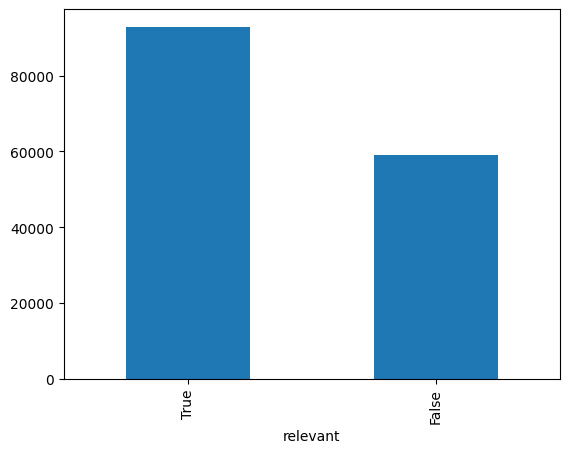

In [52]:
df['relevant'].value_counts().plot(kind='bar')

<Axes: xlabel='humanitarian_label'>

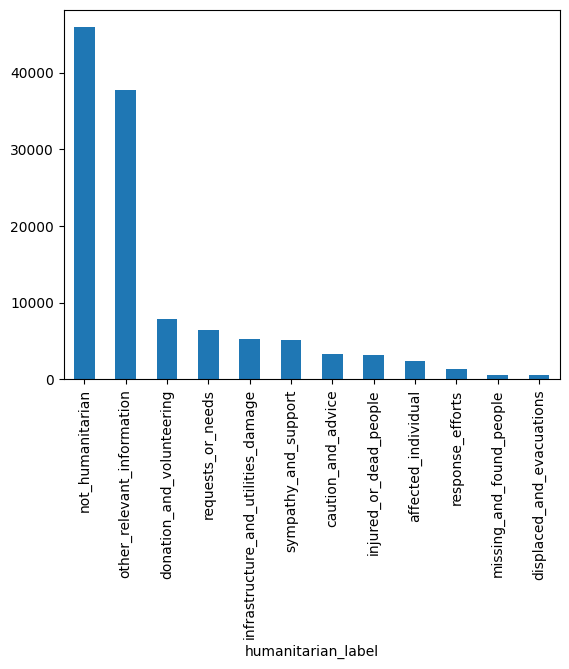

In [53]:
df['humanitarian_label'].value_counts().plot(kind='bar')

<Axes: xlabel='dataset'>

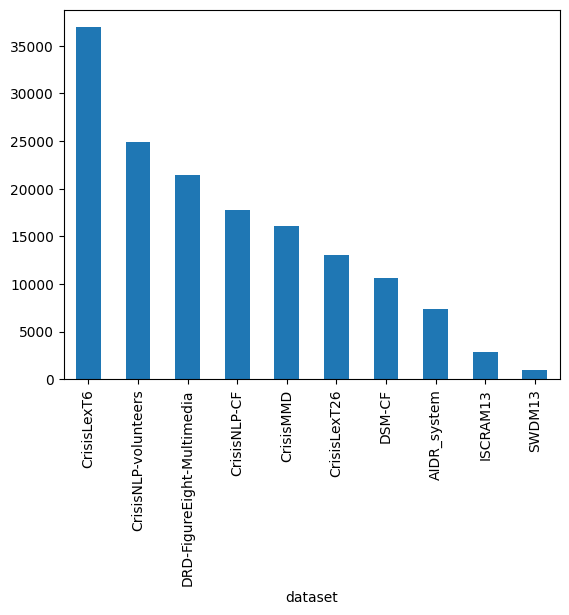

In [54]:
df['dataset'].value_counts().plot(kind='bar')

In [ ]:
import csv

df.to_csv('../data/datasets/CrisisBench.csv', index=False, quoting=csv.QUOTE_ALL)